# Logistic Regression Hyperparameter Tuning — Audio Features

This notebook tunes the SGD-based logistic regression baseline over the audio feature split, inspecting regularization strengths, learning-rate schedules, and penalty types while tracking loss/accuracy/AUC per configuration.

In [1]:
from pathlib import Path
import logging
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm.auto import tqdm

from ml.data import (
    AUDIO_FEATURES,
    RANK_COLUMN,
    create_classification_splits,
    load_classification_dataframe,
)
from ml.models import build_logistic_regression
from ml.train import train_model, plot_training_history


/Users/hallaei/miniconda3/envs/aml_cwl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

In [3]:
DATA_PATH = Path('data/datasets/Spotify_Dataset_V3.csv')
TOP_K = 10
FEATURE_SET_NAME = 'Audio Features'
HOLDOUT_FRACTION = 0.4
DEV_SHARE = 0.5
RANDOM_STATE = 51
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-3

feature_cols = AUDIO_FEATURES


In [4]:
classification_df, target_col = load_classification_dataframe(
    DATA_PATH, feature_cols, RANK_COLUMN, TOP_K, FEATURE_SET_NAME
)
train_df, dev_df, test_df = create_classification_splits(
    classification_df,
    target_col,
    HOLDOUT_FRACTION,
    DEV_SHARE,
    RANDOM_STATE,
)
print(
    f'Train={len(train_df)} Dev={len(dev_df)} Test={len(test_df)} | '
    f'Pos rates -> Train {train_df[target_col].mean():.2%}, '
    f'Dev {dev_df[target_col].mean():.2%}, Test {test_df[target_col].mean():.2%}'
)


2025-11-19 23:37:14,570 [INFO] Loading dataset from data/datasets/Spotify_Dataset_V3.csv
2025-11-19 23:37:15,425 [INFO] Prepared dataframe with 651936 songs (positive rate 4.82%).
2025-11-19 23:37:15,435 [INFO] Creating splits with holdout_fraction=0.40 and dev_share=0.50
2025-11-19 23:37:15,534 [INFO] Split sizes -> train=395328, dev=126410, test=130198
2025-11-19 23:37:15,535 [INFO] Train split positive rate: 4.73%
2025-11-19 23:37:15,535 [INFO] Dev split positive rate: 4.81%
2025-11-19 23:37:15,535 [INFO] Test split positive rate: 5.08%


Engineering Audio Features...
Train=395328 Dev=126410 Test=130198 | Pos rates -> Train 4.73%, Dev 4.81%, Test 5.08%


In [5]:
dataset_splits = {
    'Train': (train_df[feature_cols], train_df[target_col]),
    'Dev': (dev_df[feature_cols], dev_df[target_col]),
    'Test': (test_df[feature_cols], test_df[target_col]),
}
classes = sorted(train_df[target_col].unique())


## Hyperparameter grid

In [6]:
alpha_options = [1e-5, 1e-4, 1e-3, 1e-2]
learning_rate_options = ['optimal', 'invscaling', 'constant']
eta0_options = [0.001, 0.01]
penalty_options = ['l2', 'elasticnet']
l1_ratio_options = [0.0, 0.15, 0.3]
power_t_options = [0.25, 0.5]
max_iter_options = [5, 10]

search_space = []
for params in product(
    alpha_options,
    learning_rate_options,
    eta0_options,
    penalty_options,
    l1_ratio_options,
    power_t_options,
    max_iter_options,
):
    alpha, lr, eta0, penalty, l1_ratio, power_t, max_iter = params
    if penalty != 'elasticnet' and l1_ratio > 0:
        continue
    search_space.append({
        'alpha': alpha,
        'learning_rate': lr,
        'eta0': eta0,
        'penalty': penalty,
        'l1_ratio': l1_ratio,
        'power_t': power_t,
        'max_iter': max_iter,
    })

len(search_space)


384

## Training helper

In [7]:
def build_logreg_model(random_state, config):
    pipeline = build_logistic_regression(random_state)
    classifier = pipeline.named_steps['classifier']
    classifier.set_params(
        alpha=config['alpha'],
        learning_rate=config['learning_rate'],
        eta0=config['eta0'],
        penalty=config['penalty'],
        l1_ratio=config['l1_ratio'],
        power_t=config['power_t'],
        max_iter=config['max_iter'],
    )
    return pipeline


def evaluate_dev(model, dev_data):
    X_dev, y_dev = dev_data
    y_pred = model.predict(X_dev)
    dev_acc = accuracy_score(y_dev, y_pred)
    scores = model.predict_proba(X_dev)[:, 1]
    dev_auc = roc_auc_score(y_dev, scores)
    return dev_acc, dev_auc


## Run sweep

In [8]:
results = []
histories = {}
progress = tqdm(search_space, desc='LogReg configs')
for config in progress:
    config_name = (
        f"alpha={config['alpha']} lr={config['learning_rate']} eta0={config['eta0']} "
        f"penalty={config['penalty']} l1_ratio={config['l1_ratio']} power_t={config['power_t']} "
        f"iters={config['max_iter']}"
    )
    progress.set_postfix_str(config_name)
    model = build_logreg_model(RANDOM_STATE, config)
    trained_model, history_df = train_model(
        model,
        dataset_splits['Train'],
        dataset_splits['Dev'],
        epochs=MAX_EPOCHS,
        classes=classes,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    )
    dev_acc, dev_auc = evaluate_dev(trained_model, dataset_splits['Dev'])
    best_val_loss = history_df['val_loss'].min()
    results.append({
        **config,
        'best_val_loss': best_val_loss,
        'dev_accuracy': dev_acc,
        'dev_auc': dev_auc,
        'epochs_run': len(history_df),
    })
    histories[config_name] = history_df

results_df = pd.DataFrame(results).sort_values('best_val_loss').reset_index(drop=True)
results_df.head()


LogReg configs:   0%|          | 0/384 [00:00<?, ?it/s, alpha=1e-05 lr=optimal eta0=0.001 penalty=l2 l1_ratio=0.0 power_t=0.25 iters=5]2025-11-19 23:37:15,910 [INFO] Epoch 1/15 - loss: 0.2035 - val_loss: 0.2122 - accuracy: 0.9526 - val_accuracy: 0.9515 - auc: 0.5459 - val_auc: 0.4471
2025-11-19 23:37:16,459 [INFO] Epoch 2/15 - loss: 0.1950 - val_loss: 0.2003 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5519 - val_auc: 0.4960
2025-11-19 23:37:16,791 [INFO] Epoch 3/15 - loss: 0.1927 - val_loss: 0.1966 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5515 - val_auc: 0.5215
2025-11-19 23:37:17,129 [INFO] Epoch 4/15 - loss: 0.1918 - val_loss: 0.1951 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5485 - val_auc: 0.5283
2025-11-19 23:37:17,727 [INFO] Epoch 5/15 - loss: 0.1913 - val_loss: 0.1946 - accuracy: 0.9527 - val_accuracy: 0.9519 - auc: 0.5469 - val_auc: 0.5285
2025-11-19 23:37:18,097 [INFO] Epoch 6/15 - loss: 0.1911 - val_loss: 0.1944 - accuracy: 0.9527 - val_accuracy: 0.95

,alpha,learning_rate,eta0,penalty,l1_ratio,power_t,max_iter,best_val_loss,dev_accuracy,dev_auc,epochs_run
0,0.01,constant,0.01,elasticnet,0.30,0.50,10,0.192840,0.951863,0.517842,4
1,0.01,constant,0.01,elasticnet,0.30,0.25,10,0.192840,0.951863,0.517842,4
2,0.01,constant,0.01,elasticnet,0.30,0.25,5,0.192840,0.951863,0.517842,4
3,0.01,constant,0.01,elasticnet,0.30,0.50,5,0.192840,0.951863,0.517842,4
4,0.01,constant,0.01,elasticnet,0.15,0.50,10,0.193106,0.951863,0.509382,4


In [13]:
# save results_df to csv
results_df.to_csv('log_reg_hyperparameter_optimisation.csv', index=False)

## Summary statistics

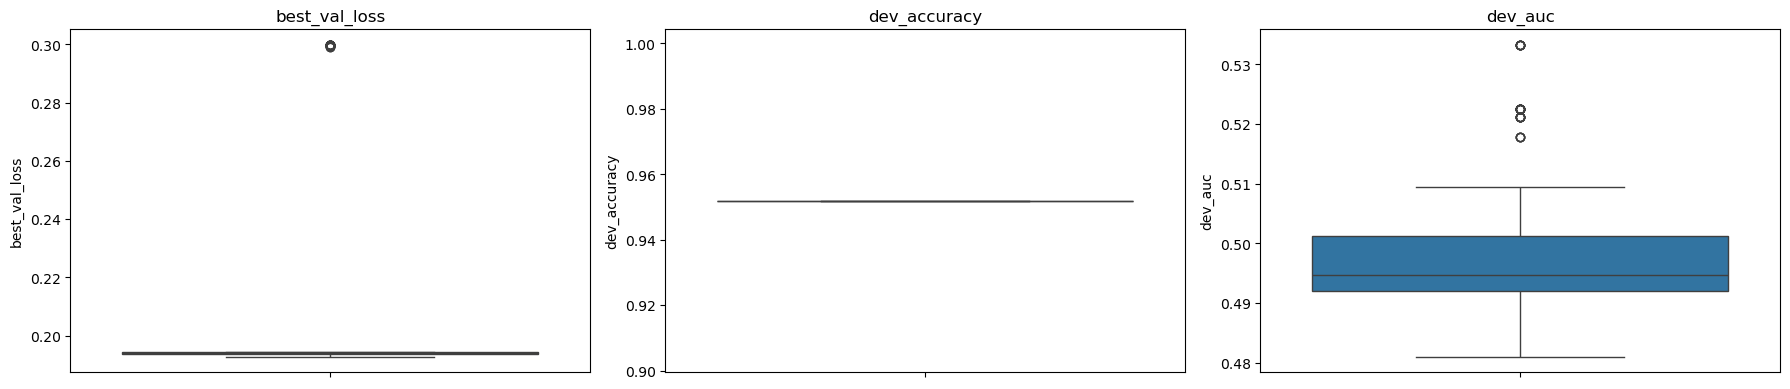

,alpha,learning_rate,eta0,penalty,l1_ratio,power_t,max_iter,best_val_loss,dev_accuracy,dev_auc
0,0.01,constant,0.010,elasticnet,0.30,0.50,10,0.192840,0.951863,0.517842
1,0.01,constant,0.010,elasticnet,0.30,0.25,10,0.192840,0.951863,0.517842
2,0.01,constant,0.010,elasticnet,0.30,0.25,5,0.192840,0.951863,0.517842
3,0.01,constant,0.010,elasticnet,0.30,0.50,5,0.192840,0.951863,0.517842
4,0.01,constant,0.010,elasticnet,0.15,0.50,10,0.193106,0.951863,0.509382
5,0.01,constant,0.010,elasticnet,0.15,0.50,5,0.193106,0.951863,0.509382
6,0.01,constant,0.010,elasticnet,0.15,0.25,10,0.193106,0.951863,0.509382
7,0.01,constant,0.010,elasticnet,0.15,0.25,5,0.193106,0.951863,0.509382
8,0.01,invscaling,0.001,elasticnet,0.30,0.25,5,0.193146,0.951863,0.487893
9,0.01,invscaling,0.001,elasticnet,0.30,0.25,10,0.193146,0.951863,0.487893


In [10]:
metrics = ['best_val_loss', 'dev_accuracy', 'dev_auc']
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
for ax, metric in zip(axes, metrics):
    sns.boxplot(data=results_df, y=metric, ax=ax)
    ax.set_title(metric)
plt.tight_layout()
plt.show()

results_df[['alpha', 'learning_rate', 'eta0', 'penalty', 'l1_ratio', 'power_t', 'max_iter', 'best_val_loss', 'dev_accuracy', 'dev_auc']].head(10)


## Hyperparameter effects

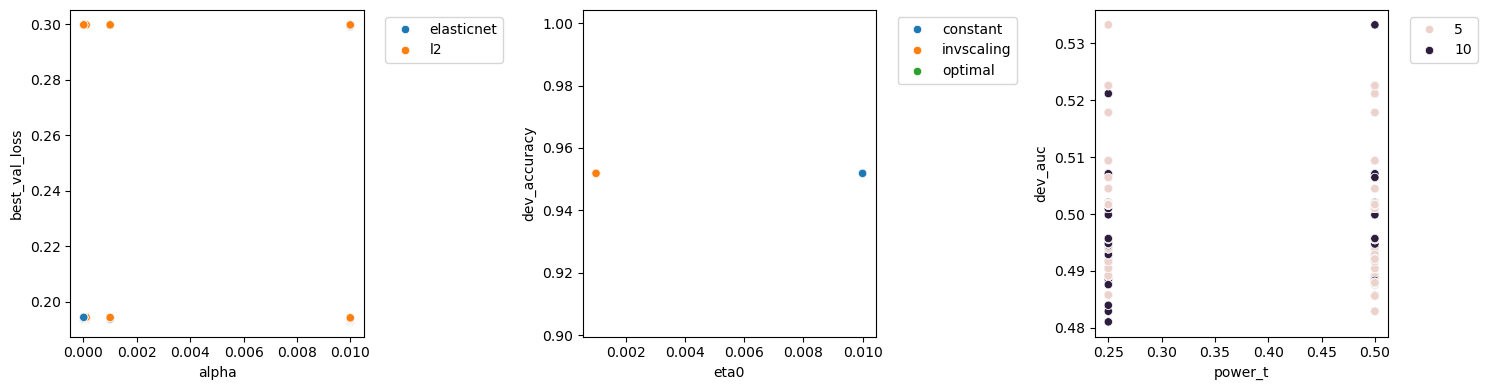

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=results_df, x='alpha', y='best_val_loss', hue='penalty', ax=axes[0])
sns.scatterplot(data=results_df, x='eta0', y='dev_accuracy', hue='learning_rate', ax=axes[1])
sns.scatterplot(data=results_df, x='power_t', y='dev_auc', hue='max_iter', ax=axes[2])
for ax in axes:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Inspect top runs

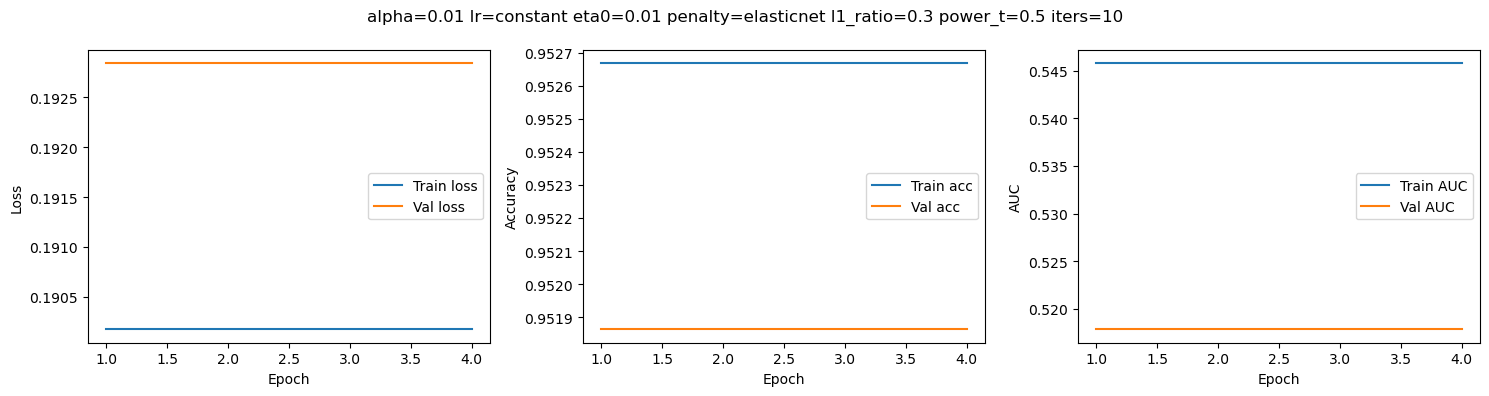

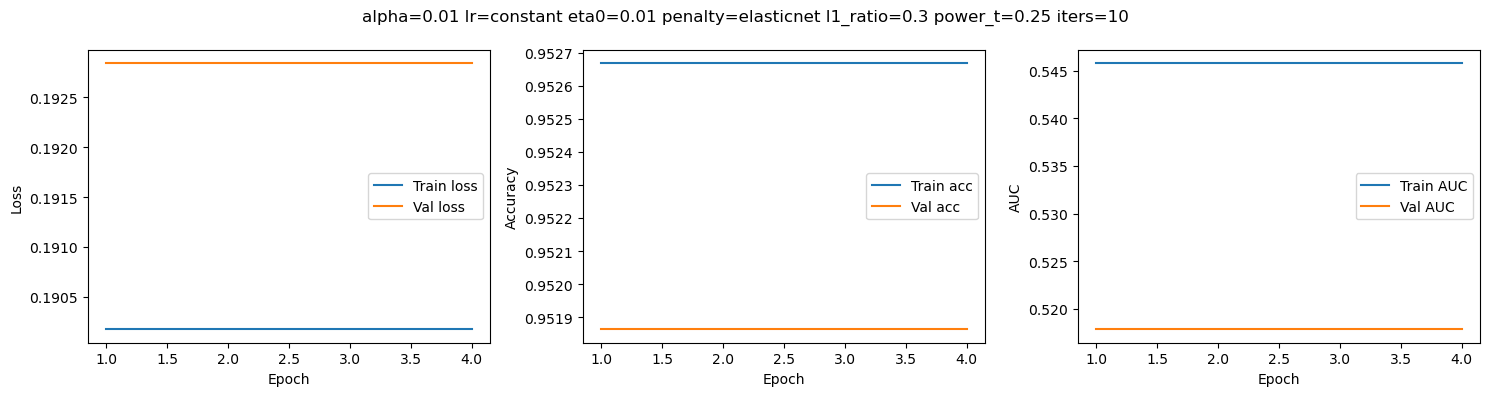

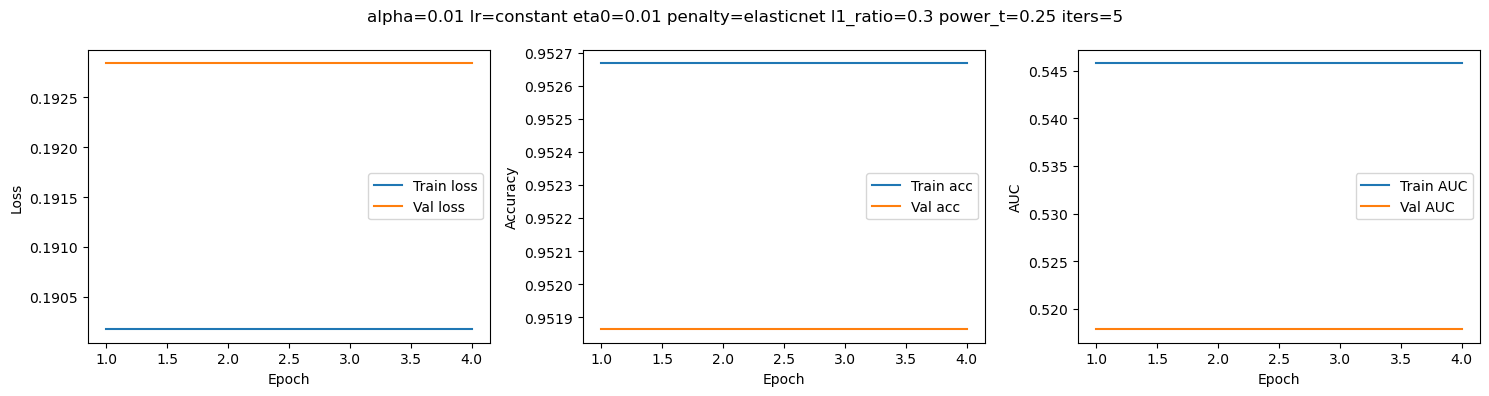

In [12]:
top_runs = results_df.head(3)
for _, row in top_runs.iterrows():
    key = (
        f"alpha={row['alpha']} lr={row['learning_rate']} eta0={row['eta0']} "
        f"penalty={row['penalty']} l1_ratio={row['l1_ratio']} power_t={row['power_t']} "
        f"iters={row['max_iter']}"
    )
    fig = plot_training_history(histories[key], title=key)
    plt.show()
